# **Peliculas 2025**

Estaremos usando dataframes que contienen informacion sobre las reseñas de peliculas estrenadas hasta marzo del 2025. En los dataframes tenemos mas de 600 mil opiniones de critica especializada y de usuarios normales y mas de 16 mil peliculas, sin embargp nos enfocaremos en las peliculas unicamente lanzadas en el año 2025 para conseguir objetivos como: 

***Hacer una comparación entre crítica y público***

- Analizar qué tan alineadas están las opiniones de los críticos profesionales (metascore) y los usuarios (userscore).

- Identificar películas “divisivas”, es decir, aquellas donde la percepción entre críticos y público difiere notablemente.

- Visualizar las distribuciones de puntajes y casos extremos para comprender patrones de discrepancia.

***Visualizar tendencias de géneros cinematográficos en 2025***

- Investigar qué géneros fueron más populares y mejor evaluados durante 2025.

- Analizar cantidad de estrenos, puntuaciones promedio, y el sentimiento general por género.

- Visualizaremos lo anterior gráficamente.

***Hacer una predicción de éxito crítico***

- Construir un modelo predictivo que clasifique las películas en categorías de "éxito", "normal", o "fracaso" según su recepción crítica.

- Usar como variables predictoras información disponible antes del estreno: género, duración, compañías productoras, director, etc.

- Evaluar el modelo con métricas de clasificación (accuracy, recall, F1 score).

**Descricpión de los dataframes**

En *movies*

- id: Identificador único de la película. Sirve para unir con el dataframe de reseñas.

- title:	Título de la película.

- releaseDate: Fecha de estreno.

- rating: Clasificación por edades (PG, R, Not Rated, etc.).

- genres: Lista separada por comas de géneros (Drama, Comedy, etc.).
description	Sinopsis o resumen de la trama.

- duration:	Duración de la película (en minutos).

- tagline: Frase promocional o lema de la película.

- metascore: Puntuación de críticos (fuente como Metacritic), generalmente de 0 a 100.

- metascore_count: Número de reseñas de críticos usadas para calcular el metascore.

- metascore_sentiment: Sentimiento general de los críticos: “Generally favorable”, “Mixed or average”, etc.
userscore	Puntuación media de usuarios (normalmente en escala de 0 a 100).

- userscore_count: Número de usuarios que puntuaron la película.

- userscore_sentiment: Sentimiento agregado de los usuarios. Similar al de críticos, pero para usuarios.

- production_companies:	Empresas productoras involucradas (separadas por comas).

- director:	Director(es) de la película.

- writer: Guionista(s) principales.

- top_cast:	Actores/actrices principales (separados por comas).

En *reviews*

- id: Mismo ID de película .

- title: Título de la película.

- quote: Fragmento textual de la reseña (puede usarse para análisis de sentimiento).

- score: Puntuación numérica dada por el usuario o crítico (no sabemos escala exacta, pero parece de 0 a 100).

- date: Fecha en que se escribió la reseña.

- author: Nombre del autor de la reseña.

- publicationName: Medio donde fue publicada la reseña (solo aplica para críticos). 

- review_type: Tipo de reseña: “user” o “critic”. Muy útil para separar y comparar percepciones.


In [350]:
# Importamos las librerías necesarias y los dataframes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score



movies = pd.read_csv('movies.csv')
reviews = pd.read_csv('movies_reviews.csv')

Ahora observamos el estado de los dataframes

In [351]:
movies.info()
movies.sample(6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16540 entries, 0 to 16539
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    16540 non-null  int64  
 1   title                 16540 non-null  object 
 2   releaseDate           16540 non-null  object 
 3   rating                14984 non-null  object 
 4   genres                16535 non-null  object 
 5   description           16540 non-null  object 
 6   duration              16540 non-null  int64  
 7   tagline               11783 non-null  object 
 8   metascore             16530 non-null  float64
 9   metascore_count       16540 non-null  int64  
 10  metascore_sentiment   16530 non-null  object 
 11  userscore             16539 non-null  float64
 12  userscore_count       16539 non-null  float64
 13  userscore_sentiment   12940 non-null  object 
 14  production_companies  16521 non-null  object 
 15  director           

,id,title,releaseDate,rating,genres,description,duration,tagline,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,production_companies,director,writer,top_cast
2651,2000543567,How to Change the World,2015-09-09,Not Rated,"Documentary,Adventure,Biography,History","In 1971, a group of friends sail into a nuclea...",110,The revolution will not be organized.,77.0,7,Generally favorable,0.0,3.0,NaN,"MetFilm Production,Daniel Film,Insight Product...",Jerry Rothwell,Jerry Rothwell,"Robert Hunter,Patrick Moore,Paul Watson,Rex We..."
11561,2000557407,Quasi,2023-04-20,R,"Comedy,Drama",Broken Lizard's spoof finds a hapless hunchbac...,99,Every Day is Hump Day,51.0,8,Mixed or average,46.0,7.0,Mixed or average,"Broken Lizard Industries,Broken Lizard Product...",Kevin Heffernan,"Jay Chandrasekhar,Kevin Heffernan,Steve Lemme,...","Brian Cox,Steve Lemme,Jay Chandrasekhar,Kevin ..."
1911,2000553288,Ham on Rye,2020-10-23,TV-14,"Drama,Mystery",A bizarre rite of passage at the local deli de...,85,"It's the most important day of your life, try ...",80.0,7,Generally favorable,24.0,7.0,Generally unfavorable,"Tago Clearing Film Studio,Omnes Films,Factory ...",Tyler Taormina,"Tyler Taormina,Eric Berger","Haley Bodell,Audrey Boos,Gabriella Herrera,Ada..."
5123,2000552713,The Bellboy,1960-07-06,Approved,Comedy,Mute bellboy Stanley works at the luxurious Fo...,72,He's the Silliest!!! - In a Series of Sequence...,70.0,7,Generally favorable,0.0,1.0,NaN,"Jerry Lewis Pictures,Paramount Pictures,Paramo...",Jerry Lewis,Jerry Lewis,"Jerry Lewis,Alex Gerry,Bob Clayton,Sonnie Sand..."
13788,2000543757,Burnt,2015-10-30,R,"Comedy,Drama",Chef Adam Jones (Bradley Cooper) had it all – ...,101,Never underestimate a man with nothing to lose.,42.0,28,Mixed or average,58.0,120.0,Mixed or average,"3 Arts Entertainment,Double Feature Films,PeaP...",John Wells,"Steven Knight,Michael Kalesniko","Bradley Cooper,Sienna Miller,Daniel Brühl,Ricc..."
2475,2000518961,The Betrayal - Nerakhoon,2008-11-21,NaN,Documentary,"Shot over the course of 23 years, Thavi narrat...",96,NaN,78.0,10,Generally favorable,0.0,2.0,NaN,"P.O.V.,The American Documentary,isotopefilms,C...","Ellen Kuras,Thavisouk Phrasavath","Ellen Kuras,Thavisouk Phrasavath",Thavisouk Phrasavath


In [352]:
reviews.info()
reviews.sample(6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 667536 entries, 0 to 667535
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   id               667536 non-null  int64 
 1   title            667536 non-null  object
 2   quote            667506 non-null  object
 3   score            667536 non-null  int64 
 4   date             509943 non-null  object
 5   author           667071 non-null  object
 6   publicationName  328586 non-null  object
 7   review_type      667536 non-null  object
dtypes: int64(2), object(6)
memory usage: 40.7+ MB


,id,title,quote,score,date,author,publicationName,review_type
302916,2000518779,Indiana Jones and the Kingdom of the Crystal S...,"No where near as bad as people say, probably e...",80,2018-07-02,Batman2752,NaN,user
453666,2000551079,Wasp Network,One can see the craftsmanship and skill with a...,63,2020-06-19,Brian Tallerico,RogerEbert.com,critic
553788,2000553629,The Marksman,The Marksman is perfectly watchable old man re...,50,2021-01-16,Matt Fowler,IGN,critic
140557,2000500027,A Single Man,It relies on a singularly brilliant performanc...,80,NaN,Bill Goodykoontz,Arizona Republic,critic
404659,2000543647,Snowden,"Snowden has a secret weapon, and it’s one that...",83,2016-09-15,Drew McWeeny,Hitfix,critic
225384,2000535998,Mesrine: Killer Instinct,"Cassel is convincing and riveting as Mesrine, ...",67,NaN,Tasha Robinson,The A.V. Club,critic


**Preprocesamiento de los datos**

Observamos que los formatos de as fechas no son los correctos, por lo que tambien debemos cambiar esto

In [353]:
# Convertimos 'releaseDate' en movies al formato adecuado
movies['releaseDate'] = pd.to_datetime(movies['releaseDate'], errors='coerce')

# Convertimos de la misma forma 'date' en reviews
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')


Ahora revisemos los valores nulos

In [354]:
# Valores nulos en movies
print("Valores nulos en 'movies':")
print(movies.isnull().sum().sort_values(ascending=False))

# Valores nulos en reviews
print("\nValores nulos en 'reviews':")
print(reviews.isnull().sum().sort_values(ascending=False))


Valores nulos en 'movies':
tagline                 4757
userscore_sentiment     3600
rating                  1556
writer                   965
top_cast                 153
releaseDate              128
production_companies      19
director                  10
metascore_sentiment       10
metascore                 10
genres                     5
userscore_count            1
userscore                  1
id                         0
title                      0
metascore_count            0
description                0
duration                   0
dtype: int64

Valores nulos en 'reviews':
publicationName    338950
date               157593
author                465
quote                  30
score                   0
title                   0
id                      0
review_type             0
dtype: int64


En los casos donde se vea la necesidad eliminaremos las filas nulas.

In [355]:
# Creamos una columna con el año de lanzamiento
movies['release_year'] = movies['releaseDate'].dt.year

# Filtramos películas de 2025
movies_2025 = movies[movies['release_year'] == 2025].copy()

# Eliminamos filas con nulos en columnas clave
cols_relevantes = ['genres', 'userscore', 'metascore']
movies_2025 = movies_2025.dropna(subset=cols_relevantes)


Por ultimo verificaremos duplicados 

In [356]:
# Verificar duplicados completos 
duplicados_movies = movies_2025.duplicated()
print(f'Duplicados exactos en movies_2025: {duplicados_movies.sum()}')

# Duplicados por ID
duplicados_por_id = movies_2025.duplicated(subset='id')
print(f'Duplicados por ID en movies_2025: {duplicados_por_id.sum()}')


# Duplicados exactos 
duplicados_reviews = reviews.duplicated()
print(f'Duplicados exactos en reviews: {duplicados_reviews.sum()}')

# Duplicados por ID y autor (puede haber múltiples reseñas por película, pero no por mismo autor)
duplicados_reseña = reviews.duplicated(subset=['id', 'author'])
print(f'Duplicados de reseña por mismo autor y película: {duplicados_reseña.sum()}')


Duplicados exactos en movies_2025: 0
Duplicados por ID en movies_2025: 0
Duplicados exactos en reviews: 0
Duplicados de reseña por mismo autor y película: 4425


Para evitar problemas eliminaremos los duplicados de reseña por mismo autor y pelicula. De esta manera cada persona solo influira una vez por pelicula.

In [357]:
reviews = reviews.drop_duplicates(subset=['id', 'author'], keep='first')


**Análisis Exploratorio de Datos**

***- Alineación entre críticos y usuarios***

In [358]:
movies_2025[['metascore', 'userscore']].describe()


,metascore,userscore
count,97.000000,97.000000
mean,63.907216,28.639175
std,13.713651,31.446113
min,32.000000,0.000000
25%,56.000000,0.000000
50%,65.000000,0.000000
75%,74.000000,60.000000
max,88.000000,91.000000


Una distribución así de extrema es bastante anormal (hablando de las calificaciones de los usuarios ya que mas del 50% de las peliculas tienen 0).

Veamos que porcentaje tiene un userscore de 0, el conteo de userscore y las que si son mayores a 0. tambien sera relevante ver si hay userscore_sentiment vacíos donde hay 0:

In [359]:
# El porcentaje con 0
zero_userscore_pct = (movies_2025['userscore'] == 0).mean() * 100
print(f"Porcentaje de películas con userscore = 0: {zero_userscore_pct:.2f}%")


Porcentaje de películas con userscore = 0: 50.52%


In [360]:
# El conteo 
movies_2025.loc[movies_2025['userscore'] == 0, 'userscore_count'].describe()

count    49.00000
mean      0.55102
std       1.02187
min       0.00000
25%       0.00000
50%       0.00000
75%       1.00000
max       3.00000
Name: userscore_count, dtype: float64

In [361]:
# Los que si son mayores a 0
movies_2025.loc[movies_2025['userscore'] > 0, 'userscore_count'].describe()

count     48.000000
mean      57.687500
std       98.632168
min        4.000000
25%        7.000000
50%       24.000000
75%       64.500000
max      493.000000
Name: userscore_count, dtype: float64

In [362]:
# userscore_sentiment vacíos
movies_2025.loc[movies_2025['userscore'] == 0, 'userscore_sentiment'].isna().mean()

np.float64(1.0)

Confirmamos que mas del 50% tienen 0, pero descubrimos varias cosas:

- Para esas películas el userscore_count es esencialmente 0 o 1, o sea, casi nadie votó. Además el campo userscore_sentiment está completamente vacío (100%).
- Las películas con userscore > 0 tienen en promedio 57 votos, y una distribución normal de participación.

Solo por si acaso revisaremos userscore_sentiment para asegurarnos de que no hay formatos incorrectos que eviten que podamos ver el contenido de esas celdas y que efectivamente hay 0 o valores vacíos.

In [363]:
# Mostrar una muestra de los valores NO nulos
movies_2025['userscore_sentiment'].dropna().sample(10, random_state=42)


8202     Generally favorable
12983       Mixed or average
8059        Mixed or average
14531       Mixed or average
7418        Mixed or average
11485       Mixed or average
4128     Generally favorable
6719     Generally favorable
1185     Generally favorable
7788        Mixed or average
Name: userscore_sentiment, dtype: object

In [364]:
# Ver los valores únicos
movies_2025['userscore_sentiment'].dropna().unique()


array(['Generally favorable', 'Universal acclaim', 'Mixed or average',
       'Generally unfavorable', 'Overwhelming dislike'], dtype=object)

In [365]:
# Ver si hay valores "vacíos" que no son NaN (como strings vacíos o espacios)
movies_2025[movies_2025['userscore_sentiment'].notna() & (movies_2025['userscore_sentiment'].str.strip() == '')]


,id,title,releaseDate,rating,genres,description,duration,tagline,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,production_companies,director,writer,top_cast,release_year


Ahora que confirmamos lo anterior rellenaremos los valores vacíos con NaN

In [366]:
# Reemplazar strings vacíos o solo espacios con NaN (por si acaso)
movies_2025['userscore_sentiment'] = movies_2025['userscore_sentiment'].replace(r'^\s*$', np.nan, regex=True)


Ahora profundicemos con una visualización:

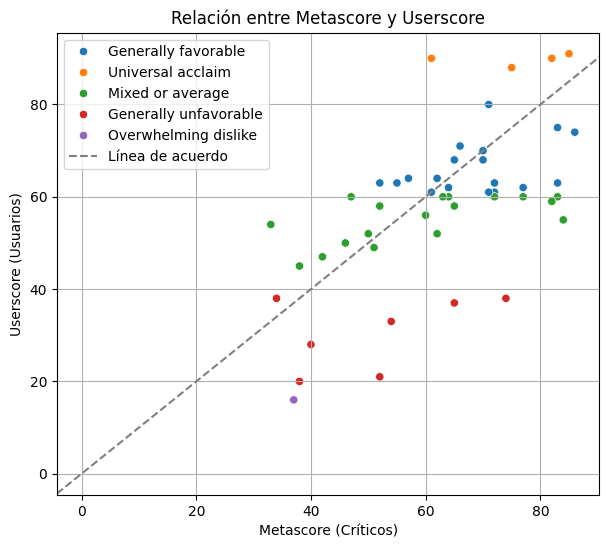

In [367]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=movies_2025, x='metascore', y='userscore', hue='userscore_sentiment')
plt.title('Relación entre Metascore y Userscore')
plt.xlabel('Metascore (Críticos)')
plt.ylabel('Userscore (Usuarios)')
plt.axline((0, 0), slope=1, color='gray', linestyle='--', label='Línea de acuerdo')
plt.legend()
plt.grid(True)
plt.show()


El gráfico de dispersión revela una correlación positiva entre las puntuaciones otorgadas por críticos (Metascore) y por usuarios (Userscore), lo que indica que, en general, las películas bien valoradas por la crítica también tienden a gustar al público. Sin embargo, también se observan varios puntos alejados de la línea de acuerdo (línea diagonal), lo que refleja casos donde hay una diferencia significativa entre ambas percepciones. Las películas con sentimientos “Generally favorable” o incluso “Universal acclaim” por parte de los usuarios suelen alinearse con puntajes altos de los críticos, pero hay casos notables en los que los usuarios dan puntuaciones mucho más bajas que los críticos, y viceversa. 

Hay que ver las películas que resultan mas divisivas entre la crítica y la audiencia. Para hacerlo tomaremos en cuenta solo userscores validos:

In [368]:
# Tomamos solo los scores con valores reales o validos
valid_scores = movies_2025[movies_2025['userscore'] > 0].copy()


In [369]:
# Observamos la correlación entre metascore y userscore
correlación = valid_scores['metascore'].corr(valid_scores['userscore'])
print(f"Correlación entre metascore y userscore (sin ceros): {correlación:.2f}")


Correlación entre metascore y userscore (sin ceros): 0.63


In [370]:
# Mostramos peliculas mas divisivas con una discrepancia de 20 minimo
valid_scores['score_diff'] = abs(valid_scores['metascore'] - valid_scores['userscore'])
discrepantes = valid_scores[valid_scores['score_diff'] > 20]
print(f"Número de películas con diferencia >20 puntos: {len(discrepantes)} de {len(valid_scores)}")


discrepantes[['title', 'metascore', 'userscore', 'score_diff']]


Número de películas con diferencia >20 puntos: 10 de 48


,title,metascore,userscore,score_diff
1096,Universal Language,84.0,55.0,29.0
1169,Jazzy,83.0,60.0,23.0
1353,Grand Theft Hamlet,82.0,59.0,23.0
3601,Eternal You,74.0,38.0,36.0
6947,Night Call,65.0,37.0,28.0
8277,Armand,61.0,90.0,29.0
10607,The Witcher: Sirens of the Deep,54.0,33.0,21.0
11406,Cleaner,52.0,21.0,31.0
14740,Star Trek: Section 31,37.0,16.0,21.0
15349,Old Guy,33.0,54.0,21.0


Podemos ver que 10 películas de un total de 48 (aproximadamente el 21%) que presentan una discrepancia mayor a 20 puntos entre Metascore y Userscore, lo cual es un porcentaje considerable. Títulos como Universal Language (84 de críticos vs. 55 de usuarios) o Armand (61 de críticos vs. 90 de usuarios) destacan por mostrar juicios muy distintos entre ambos grupos. Este fenómeno podría deberse a varios factores como expectativas del público, marketing engañoso, temas controversiales, o diferencias en criterios de evaluación. Estos casos ilustran que una buena recepción por parte de la crítica no garantiza necesariamente una buena aceptación por parte del público, y viceversa, lo que refuerza la importancia de considerar ambos puntos de vista al analizar el impacto de una película.

Visualicemos con histogramas y un scatter plot de la alineación:

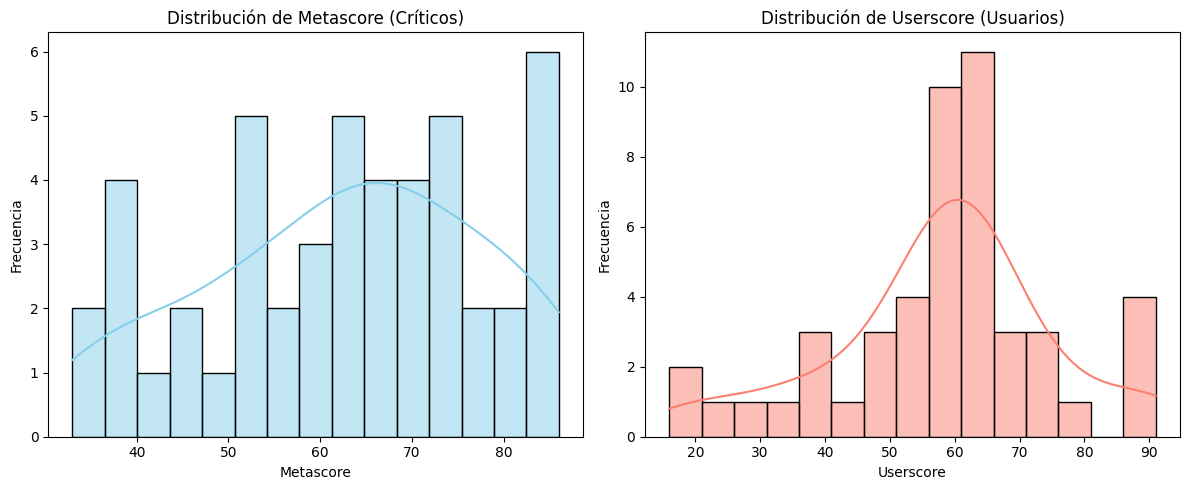

In [371]:
# Filtramos solo las películas con userscore > 0
valid_scores = movies_2025[movies_2025['userscore'] > 0].copy()

plt.figure(figsize=(12, 5))

# Histograma de Metascore
plt.subplot(1, 2, 1)
sns.histplot(valid_scores['metascore'], bins=15, kde=True, color='skyblue')
plt.title('Distribución de Metascore (Críticos)')
plt.xlabel('Metascore')
plt.ylabel('Frecuencia')

# Histograma de Userscore
plt.subplot(1, 2, 2)
sns.histplot(valid_scores['userscore'], bins=15, kde=True, color='salmon')
plt.title('Distribución de Userscore (Usuarios)')
plt.xlabel('Userscore')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

El histograma del Metascore muestra que las puntuaciones de los críticos están distribuidas de manera relativamente uniforme, aunque con una ligera tendencia hacia valores altos, lo que indica que la crítica ha sido en su mayoría positiva hacia las películas de 2025. No se observan extremos pronunciados, lo que sugiere una evaluación equilibrada, sin que la mayoría de los filmes sean calificados como sobresalientes ni como desastrosos. En cambio, el histograma del Userscore revela una distribución más concentrada en la franja de 55 a 65 puntos, con menos casos en los extremos, lo que sugiere una mayor moderación por parte de los usuarios o una mayor homogeneidad en sus experiencias. Esta diferencia en la forma de las distribuciones indica que, aunque ambas partes suelen coincidir, los críticos tienden a utilizar un rango más amplio de calificaciones.

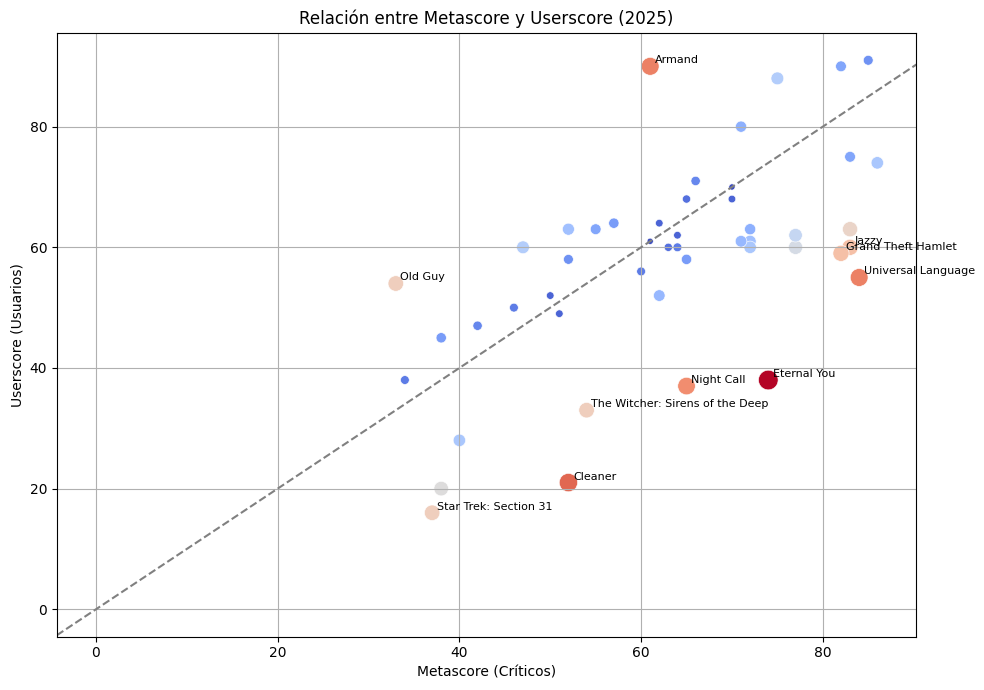

In [372]:
# Calculamos la diferencia
valid_scores['score_diff'] = abs(valid_scores['metascore'] - valid_scores['userscore'])

# Definimos las películas divisivas
divisivas = valid_scores[valid_scores['score_diff'] > 20]

# Crear gráfico
plt.figure(figsize=(10, 7))

# Scatter plot
sns.scatterplot(
    data=valid_scores,
    x='metascore',
    y='userscore',
    hue='score_diff',
    size='score_diff',
    palette='coolwarm',
    sizes=(20, 200),
    legend=False
)

# Línea de igualdad
plt.axline((0, 0), slope=1, linestyle='--', color='gray')

# Añadir etiquetas a las más divisivas
for _, row in divisivas.iterrows():
    plt.text(row['metascore'] + 0.5, row['userscore'] + 0.5, row['title'], fontsize=8)

plt.title('Relación entre Metascore y Userscore (2025)')
plt.xlabel('Metascore (Críticos)')
plt.ylabel('Userscore (Usuarios)')
plt.grid(True)
plt.tight_layout()
plt.show()

En este gráfico de dispersión podemos visualizar de manera más clara qué tan alineadas están las opiniones de críticos y usuarios, destacando con mayor tamaño y color las películas que presentan una diferencia de más de 20 puntos entre ambas métricas. Se observa que la mayoría de las películas se concentran cerca de la línea de igualdad, lo que indica concordancia entre ambos grupos. Sin embargo, las películas más divisivas como Eternal You, Cleaner o Armand se destacan visualmente con puntos más grandes y colores más intensos. Esto refuerza la idea de que, aunque hay una correlación general, ciertas películas provocan reacciones muy distintas entre la crítica especializada y el público general, lo cual puede ser indicativo de elementos polémicos, diferencias de expectativas o enfoques narrativos poco convencionales.

Adicionalmente veamos una distribución de los puntajes con un gráfico de densidad:

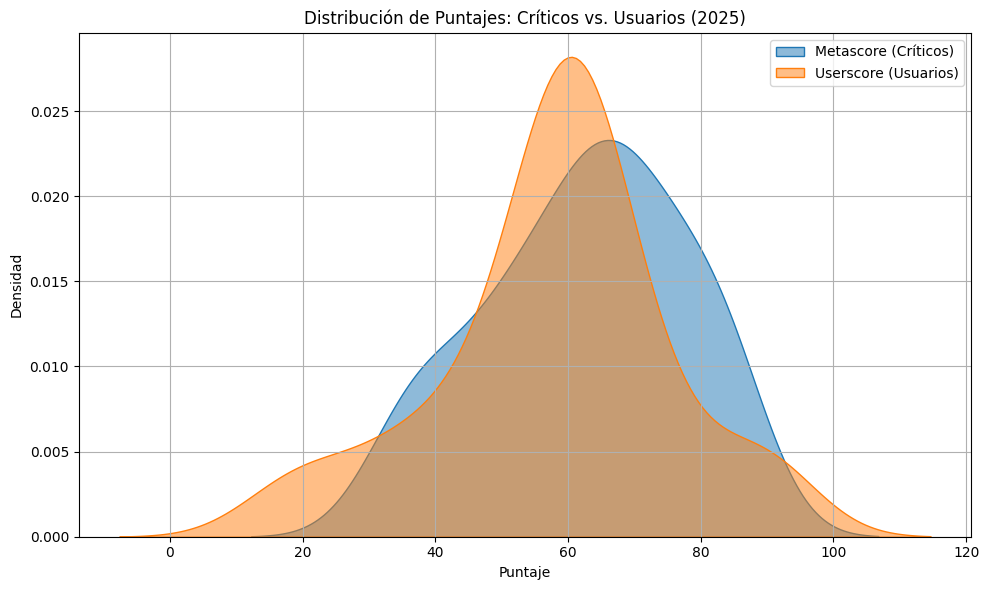

In [373]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=valid_scores, x='metascore', label='Metascore (Críticos)', fill=True, alpha=0.5)
sns.kdeplot(data=valid_scores, x='userscore', label='Userscore (Usuarios)', fill=True, alpha=0.5)

plt.title('Distribución de Puntajes: Críticos vs. Usuarios (2025)')
plt.xlabel('Puntaje')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


El gráfico de densidad nos muestra contrastes interesantes en la evaluación cinematográfica de 2025. La crítica especializada (Metascore) tiende a concentrarse en un rango de puntuaciones más elevado, con un pico notablemente más alto que el de las puntuaciones de los usuarios. En cambio, la distribución de las puntuaciones del público (Userscore) muestra una mayor dispersión y un pico más modesto, desplazado ligeramente hacia la izquierda en comparación con la crítica. Esta diferencia sugiere que, si bien existe un solapamiento en las valoraciones, los críticos tienden a ser más entusiastas en sus puntuaciones máximas, mientras que el público exhibe una gama más amplia de opiniones, con una tendencia a valoraciones más moderadas en general.

Veamos con la ayuda de una tabla cruzada la comparación de la opinion de los criticos y los usuarios:

In [374]:
# Filtramos películas de 2025 con ambos sentimientos disponibles
sentiment_data = movies_2025[
    movies_2025['metascore_sentiment'].notna() & 
    movies_2025['userscore_sentiment'].notna()
]

# Crear tabla cruzada
sentiment_crosstab = pd.crosstab(
    sentiment_data['metascore_sentiment'],
    sentiment_data['userscore_sentiment'],
    normalize='index'  # Normalizamos por filas para ver proporciones
)

# Mostrar tabla
sentiment_crosstab


userscore_sentiment,Generally favorable,Generally unfavorable,Mixed or average,Overwhelming dislike,Universal acclaim
metascore_sentiment,,,,,
Generally favorable,0.545455,0.090909,0.272727,0.0,0.090909
Generally unfavorable,0.000000,0.400000,0.400000,0.2,0.000000
Mixed or average,0.230769,0.230769,0.538462,0.0,0.000000
Universal acclaim,0.375000,0.000000,0.375000,0.0,0.250000


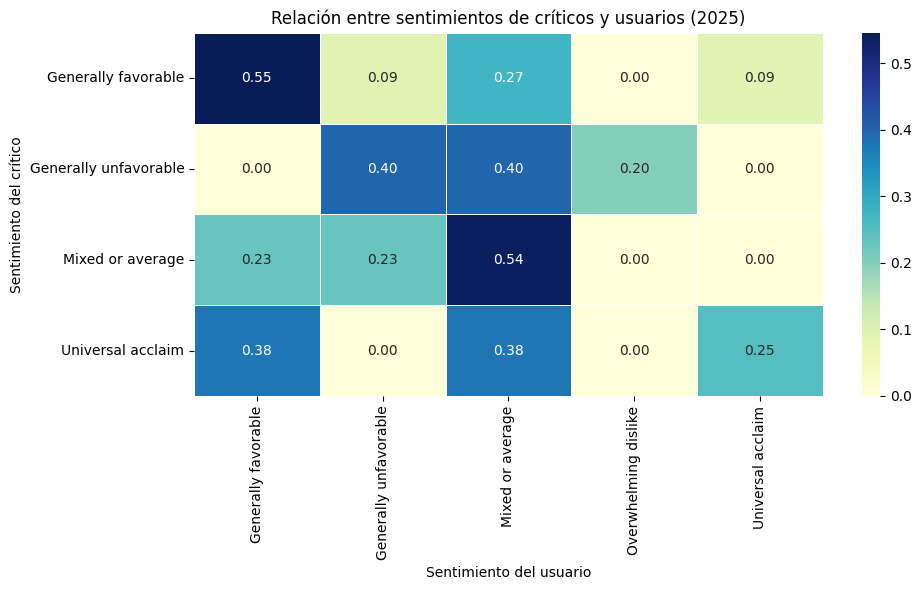

In [375]:
plt.figure(figsize=(10, 6))
sns.heatmap(sentiment_crosstab, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)

plt.title("Relación entre sentimientos de críticos y usuarios (2025)")
plt.xlabel("Sentimiento del usuario")
plt.ylabel("Sentimiento del crítico")
plt.tight_layout()
plt.show()

La comparación entre lo que opinan los críticos (metascore) y usuarios (userscore) muestra una alineación moderada, especialmente cuando ambos otorgan calificaciones “Generally favorable” (54.5%) o “Mixed or average” (53.8%), lo cual indica cierto consenso en valoraciones medias. Sin embargo, hay discrepancias notables en películas con “Universal acclaim” por parte de críticos, ya que solo el 25% recibe ese mismo entusiasmo por parte del público, y el resto tiende a considerarlas solo “favorable” o “mixtas”, revelando una brecha de percepción. Asimismo, cuando los críticos son más negativos (“Generally unfavorable”), los usuarios se dividen entre “unfavorable” (40%), “mixed” (40%) e incluso algunos las consideran extremadamente malas. Esto sugiere que aunque hay coincidencia general en calificaciones intermedias, en los extremos la percepción varía significativamente entre ambos grupos, destacando la subjetividad en la recepción cinematográfica.


Críticos y usuarios tienden a coincidir moderadamente en sus evaluaciones, pero existen casos notables de desacuerdo. El análisis de sentimientos también muestra que los críticos son ligeramente más consistentes, mientras que los usuarios tienden a emitir juicios más extremos o variados.

***- Tendencias de géneros***

Vamos a empezar analizando la cantidad de películas por género en 2025. Primero, necesitaremos obtener un resumen de cuántas películas de cada género se estrenaron ese año. 

In [376]:
# Contamos la cantidad de películas por género en 2025
genre_counts = movies_2025['genres'].str.split(',').explode().value_counts()

# Mostramos las 10 principales categorías de género
genre_counts.head(10)


genres
Drama          54
Comedy         35
Thriller       24
Action         18
Sci-Fi         16
Adventure      14
Horror         11
Crime          11
Documentary    11
Mystery        10
Name: count, dtype: int64

Ahora que tenemos un panorama mas claro de la la cantidad de peliculas estrenadas por género este año, ahora lo mas prudente sera calcular la puntuación promedio de las películas por género, visualizar la opinion general para cada género y detectar que géneros se encuentran en declive y cuales estan teniendo una mejor recepción:

In [377]:
# Puntuación promedio de userscore y metascore por género
puntuaciones_promedio = movies_2025.groupby('genres')[['userscore', 'metascore']].mean()
puntuaciones_promedio


,userscore,metascore
genres,,
"Action,Adventure,Comedy,Crime,Drama",0.000000,58.000000
"Action,Adventure,Comedy,Drama,Sci-Fi",0.000000,32.000000
"Action,Adventure,Drama,Sci-Fi",16.000000,37.000000
"Action,Adventure,Fantasy",28.000000,40.000000
"Action,Adventure,Horror,Romance,Sci-Fi",64.000000,57.000000
"Action,Adventure,Sci-Fi",47.000000,42.000000
"Action,Comedy",47.333333,37.666667
"Action,Comedy,Thriller",0.000000,59.000000
"Action,Crime",0.000000,57.000000


El análisis muestra una clara desalineación entre las opiniones de críticos y usuarios, especialmente en géneros como Action, Adventure y Comedy, donde los usuarios tienden a ser más generosos en sus calificaciones que los críticos. Por ejemplo, combinaciones de géneros como Action, Adventure, Comedy, Crime, Drama presentan un userscore de 0 y un metascore de 58, destacando la discrepancia. Sin embargo, hay géneros como Biography, Drama, History que gozan de buena aceptación tanto de críticos (85) como de usuarios (91), lo que refleja una percepción más equilibrada. En general, los usuarios parecen valorar más el entretenimiento, mientras que los críticos se enfocan más en aspectos técnicos o profundos de las películas, lo que podría explicar las diferencias observadas.

In [378]:
# Opinión de los usuarios por género
sentimiento_userscore = movies_2025.groupby('genres')['userscore_sentiment'].value_counts(normalize=True).unstack().fillna(0)
sentimiento_userscore


userscore_sentiment,Generally favorable,Generally unfavorable,Mixed or average,Overwhelming dislike,Universal acclaim
genres,,,,,
"Action,Adventure,Drama,Sci-Fi",0.0,0.000000,0.000000,1.0,0.0
"Action,Adventure,Fantasy",0.0,1.000000,0.000000,0.0,0.0
"Action,Adventure,Horror,Romance,Sci-Fi",1.0,0.000000,0.000000,0.0,0.0
"Action,Adventure,Sci-Fi",0.0,0.000000,1.000000,0.0,0.0
"Action,Comedy",0.0,0.333333,0.666667,0.0,0.0
"Action,Crime,Drama,Thriller",0.0,0.000000,1.000000,0.0,0.0
"Action,Drama,Thriller",0.0,1.000000,0.000000,0.0,0.0
"Action,Thriller",0.0,1.000000,0.000000,0.0,0.0
"Adventure,Comedy,Family,Mystery",1.0,0.000000,0.000000,0.0,0.0


In [379]:
# Opinión de los críticos por género
sentimiento_metascore = movies_2025.groupby('genres')['metascore_sentiment'].value_counts(normalize=True).unstack().fillna(0)
sentimiento_metascore 

metascore_sentiment,Generally favorable,Generally unfavorable,Mixed or average,Universal acclaim
genres,,,,
"Action,Adventure,Comedy,Crime,Drama",0.000000,0.000000,1.000000,0.000000
"Action,Adventure,Comedy,Drama,Sci-Fi",0.000000,1.000000,0.000000,0.000000
"Action,Adventure,Drama,Sci-Fi",0.000000,1.000000,0.000000,0.000000
"Action,Adventure,Fantasy",0.000000,0.000000,1.000000,0.000000
"Action,Adventure,Horror,Romance,Sci-Fi",0.000000,0.000000,1.000000,0.000000
"Action,Adventure,Sci-Fi",0.000000,0.000000,1.000000,0.000000
"Action,Comedy",0.000000,0.666667,0.333333,0.000000
"Action,Comedy,Thriller",0.000000,0.000000,1.000000,0.000000
"Action,Crime",0.000000,0.000000,1.000000,0.000000


Estas tablas muestran una limitación significativa para discernir tendencias claras por género individual. Al agrupar películas por la totalidad de sus géneros asignados, se obtienen categorías muy específicas y con pocos ejemplos, lo que dificulta la identificación de patrones generales para géneros como 'Acción', 'Comedia' o 'Drama' de forma aislada. Por ejemplo, la categoría 'Action,Adventure,Comedy,Crime,Drama' muestra un sentimiento 'Mixed or average' por parte de los críticos, pero no nos informa sobre cómo se perciben las películas de 'Acción' en general. Esta granularidad dificulta extraer conclusiones amplias sobre la recepción de géneros individuales, lo que subraya la necesidad de desglosar la columna de géneros para analizar el sentimiento asociado a cada género por separado.



In [380]:
# Separamos los géneros en múltiples categorías para poder visualizar mejor
movies_2025['categorias_genero_separadas'] = movies_2025['genres'].str.split(',')

# Convertir todas las categorías a minúsculas para evitar diferencias de mayúsculas y minúsculas
movies_2025['categorias_genero_separadas'] = movies_2025['categorias_genero_separadas'].apply(lambda x: [i.strip().lower() for i in x])

# Desplegar las categorías únicas después de la separación
all_genres = [genre for sublist in movies_2025['categorias_genero_separadas'] for genre in sublist]
unique_genres = set(all_genres)

print(f"Categorías de géneros únicas: {unique_genres}")

# Ahora, procedemos a agrupar por categorías separadas y recalcular las frecuencias
sentimiento_userscore_categoria = movies_2025.explode('categorias_genero_separadas') \
    .groupby('categorias_genero_separadas')['userscore_sentiment'] \
    .value_counts(normalize=True).unstack().fillna(0)

sentimiento_metascore_categoria = movies_2025.explode('categorias_genero_separadas') \
    .groupby('categorias_genero_separadas')['metascore_sentiment'] \
    .value_counts(normalize=True).unstack().fillna(0)

# Visualizamos la tabla de los usuarios
sentimiento_userscore_categoria



Categorías de géneros únicas: {'mystery', 'drama', 'animation', 'war', 'crime', 'horror', 'romance', 'sport', 'fantasy', 'thriller', 'adventure', 'comedy', 'music', 'history', 'documentary', 'biography', 'musical', 'family', 'sci-fi', 'action'}


userscore_sentiment,Generally favorable,Generally unfavorable,Mixed or average,Overwhelming dislike,Universal acclaim
categorias_genero_separadas,,,,,
action,0.153846,0.384615,0.384615,0.076923,0.000000
adventure,0.555556,0.222222,0.111111,0.111111,0.000000
animation,0.600000,0.200000,0.200000,0.000000,0.000000
biography,0.000000,0.000000,0.000000,0.000000,1.000000
comedy,0.473684,0.105263,0.315789,0.000000,0.105263
crime,0.200000,0.000000,0.800000,0.000000,0.000000
documentary,0.166667,0.166667,0.666667,0.000000,0.000000
drama,0.291667,0.166667,0.333333,0.041667,0.166667
family,1.000000,0.000000,0.000000,0.000000,0.000000


In [381]:
 #Visualizamos la tabla de la crítica
sentimiento_metascore_categoria

metascore_sentiment,Generally favorable,Generally unfavorable,Mixed or average,Universal acclaim
categorias_genero_separadas,,,,
action,0.166667,0.277778,0.555556,0.000000
adventure,0.357143,0.142857,0.428571,0.071429
animation,0.333333,0.000000,0.166667,0.500000
biography,0.600000,0.000000,0.000000,0.400000
comedy,0.457143,0.114286,0.285714,0.142857
crime,0.272727,0.090909,0.636364,0.000000
documentary,0.636364,0.000000,0.090909,0.272727
drama,0.518519,0.092593,0.222222,0.166667
family,0.800000,0.000000,0.000000,0.200000


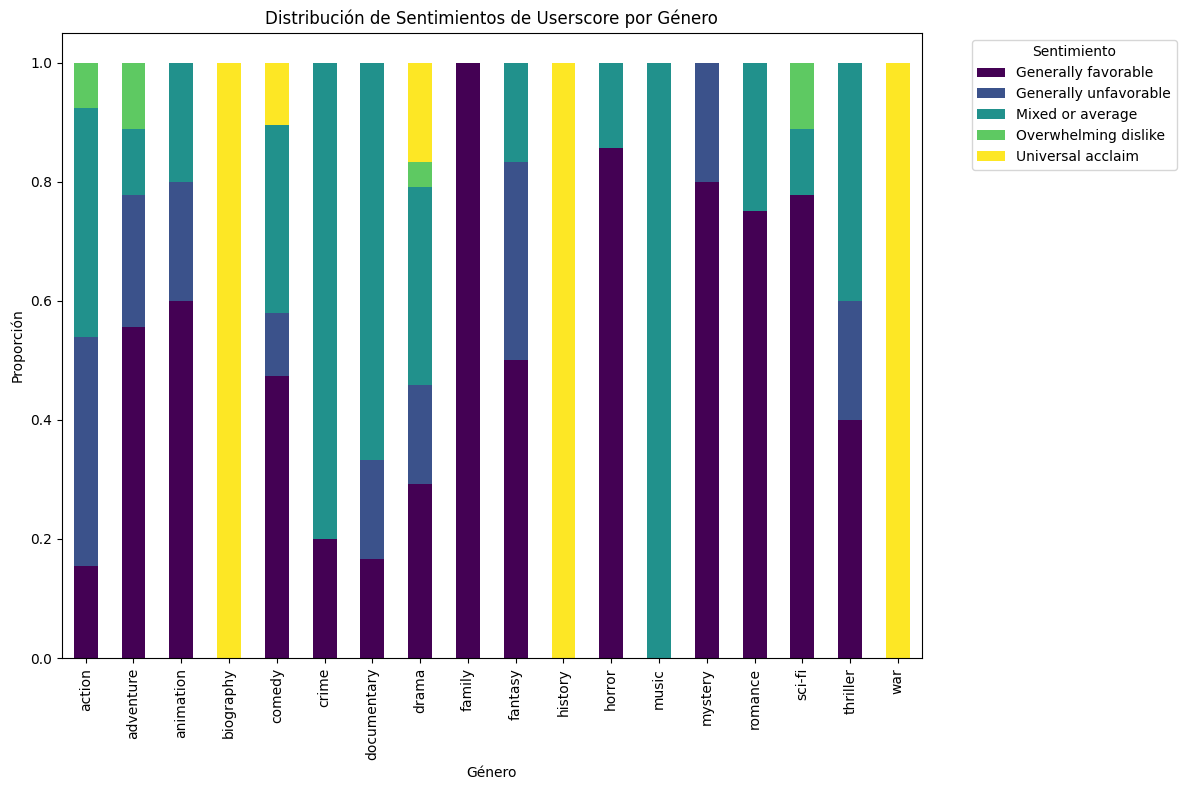

In [382]:
# Graficamos la distribución de opiniones de usuarios para cada género
userscore_sentiment_categoria = sentimiento_userscore_categoria.fillna(0)

# Crear gráfico de barras apiladas
ax = userscore_sentiment_categoria.plot(kind='bar', stacked=True, figsize=(12,8), colormap='viridis')
plt.title('Distribución de Sentimientos de Userscore por Género')
plt.xlabel('Género')
plt.ylabel('Proporción')
plt.xticks(rotation=90)
plt.legend(title="Sentimiento", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


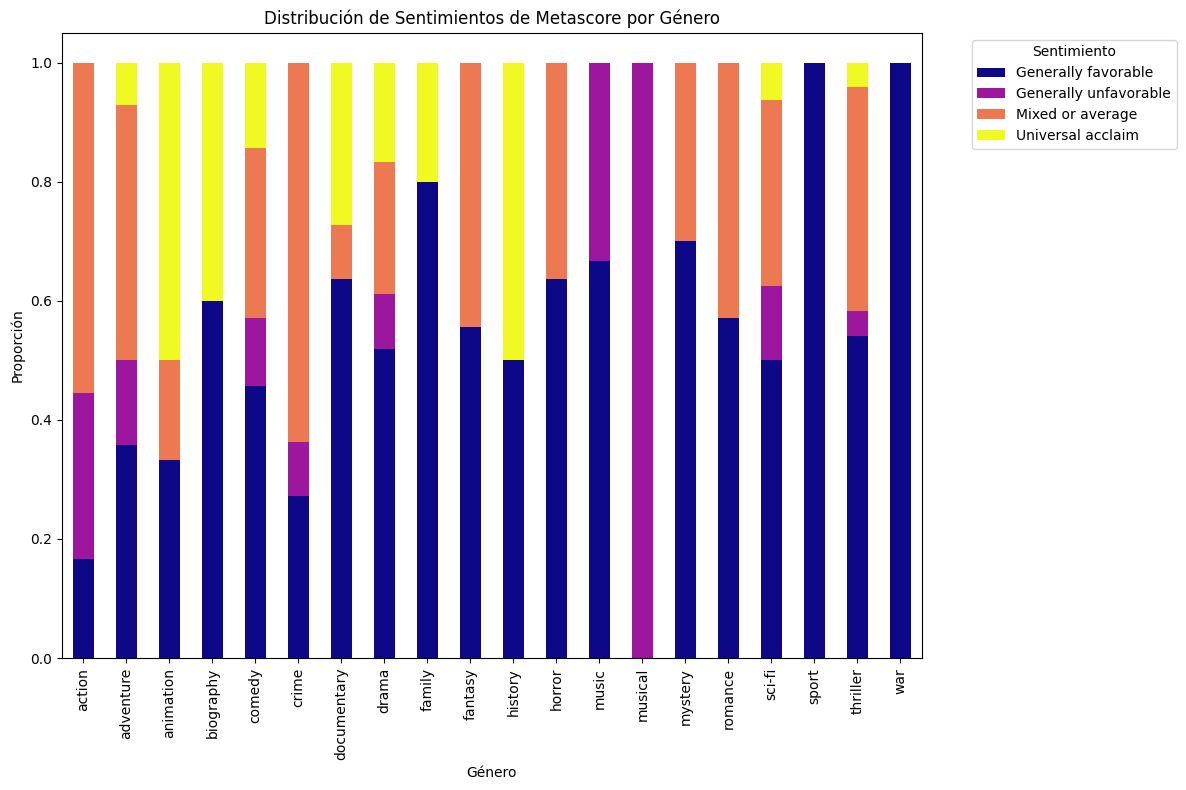

In [383]:
# Graficar la distribución de opiniones de críticos para cada género
metascore_sentiment_categoria = sentimiento_metascore_categoria.fillna(0)

# Crear gráfico de barras apiladas
ax = metascore_sentiment_categoria.plot(kind='bar', stacked=True, figsize=(12,8), colormap='plasma')
plt.title('Distribución de Sentimientos de Metascore por Género')
plt.xlabel('Género')
plt.ylabel('Proporción')
plt.xticks(rotation=90)
plt.legend(title="Sentimiento", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


En general, si bien existen áreas de acuerdo en la recepción de ciertos géneros, también se observan diferencias notables en las tendencias de opinion entre usuarios y críticos en 2025. Como hemos visto, los críticos a menudo muestran una mayor selectividad y una distribución de opiniones que puede ser más dispersa, mientras que los usuarios tienden a mostrar opiniones más polarizadas hacia los extremos positivo o negativo en algunos géneros, o una concentración en lo "Generalmente favorable" en otros. 

Ahora es momento de calcular las puntuaciones promedio de userscore y metascore para cada género individual:

In [384]:
# Desglosamos los géneros para cada película
genres_exploded = movies_2025.assign(genre=movies_2025['genres'].str.split(',')).explode('genre')

# Convertimos la columna 'genre' a minúsculas y eliminar espacios en blanco al principio/final
genres_exploded['genre'] = genres_exploded['genre'].str.lower().str.strip()

# Calculamos la puntuación promedio de userscore y metascore por género individual
puntuaciones_promedio_por_genero = genres_exploded.groupby('genre')[['userscore', 'metascore']].mean()

# Mostramos las puntuaciones promedio por género, ordenadas por Metascore descendente
print("Puntuaciones promedio por género (ordenado por Metascore):")
print(puntuaciones_promedio_por_genero.sort_values(by='metascore', ascending=False))

# Mostrar las puntuaciones promedio por género, ordenadas por Userscore descendente
print("\nPuntuaciones promedio por género (ordenado por Userscore):")
print(puntuaciones_promedio_por_genero.sort_values(by='userscore', ascending=False))

Puntuaciones promedio por género (ordenado por Metascore):
             userscore  metascore
genre                            
history      45.500000  81.000000
biography    18.200000  77.600000
animation    50.166667  74.000000
documentary  30.181818  73.727273
family       42.800000  71.200000
war          44.000000  69.500000
sport         0.000000  67.000000
romance      35.714286  66.000000
drama        26.037037  65.166667
comedy       33.657143  63.342857
horror       39.545455  62.909091
mystery      29.400000  62.900000
thriller     22.500000  62.625000
sci-fi       33.000000  60.750000
fantasy      34.888889  60.222222
music        40.000000  58.333333
adventure    33.071429  57.285714
crime        25.818182  56.818182
action       31.111111  49.500000
musical       0.000000  34.000000

Puntuaciones promedio por género (ordenado por Userscore):
             userscore  metascore
genre                            
animation    50.166667  74.000000
history      45.500000  81.0000

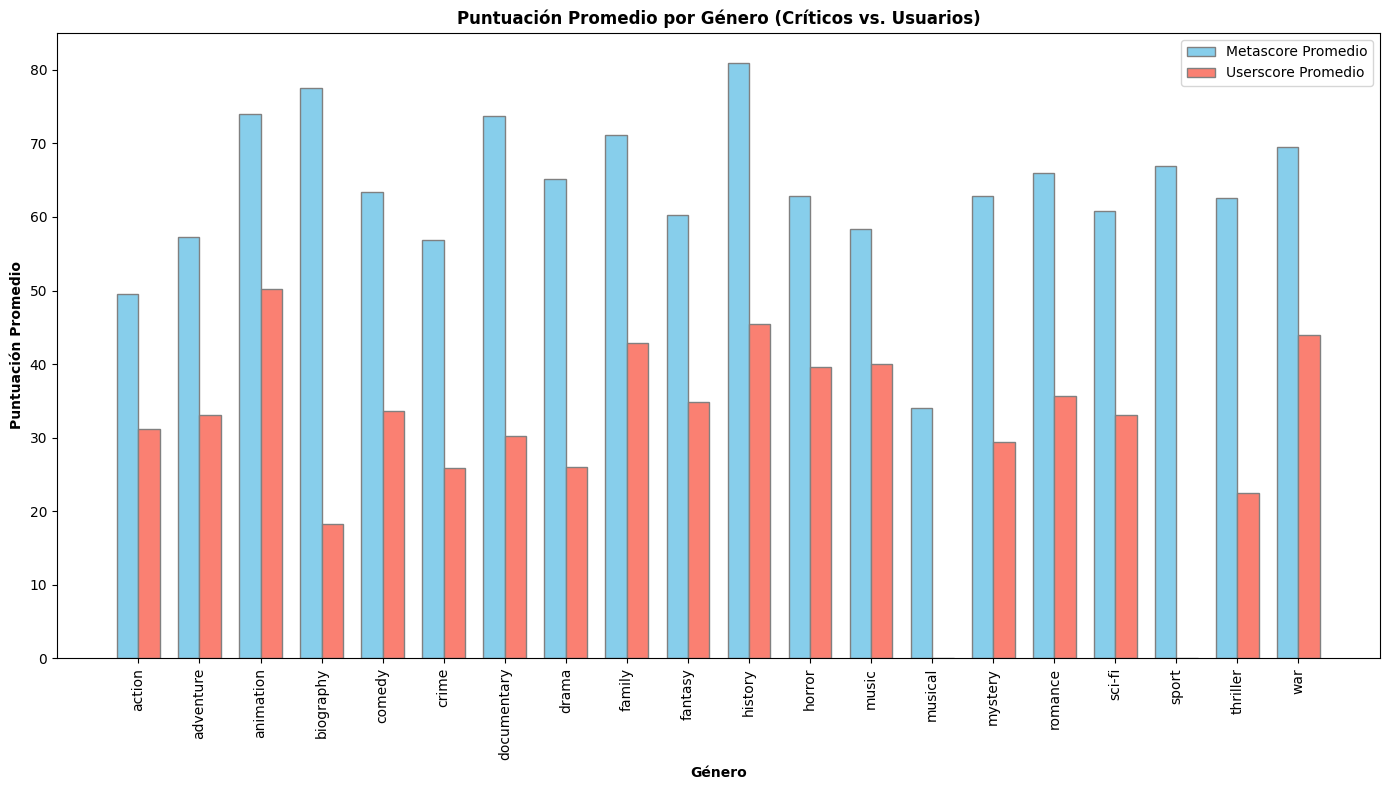

In [385]:
# Datos de las puntuaciones promedio por género
genres = puntuaciones_promedio_por_genero.index
metascores = puntuaciones_promedio_por_genero['metascore']
userscores = puntuaciones_promedio_por_genero['userscore']

# Ancho de las barras
bar_width = 0.35

# Posiciones de las barras para cada género
r1 = np.arange(len(genres))
r2 = [x + bar_width for x in r1]

# Crear el gráfico de barras
plt.figure(figsize=(14, 8))
plt.bar(r1, metascores, color='skyblue', width=bar_width, edgecolor='grey', label='Metascore Promedio')
plt.bar(r2, userscores, color='salmon', width=bar_width, edgecolor='grey', label='Userscore Promedio')

# Añadir etiquetas en el eje x (géneros)
plt.xlabel('Género', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(genres))], genres, rotation=90)

# Añadir etiquetas en el eje y
plt.ylabel('Puntuación Promedio', fontweight='bold')
plt.title('Puntuación Promedio por Género (Críticos vs. Usuarios)', fontweight='bold')

# Añadir leyenda
plt.legend()

# Ajustar el layout para evitar que las etiquetas se superpongan
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Los géneros de Animación, Historia, Guerra y Familiar parecen tener una recepción positiva tanto por la crítica como por el público en promedio. Sin embargo, existen diferencias notables en la valoración de géneros como Biografía y Documental, que son más apreciados por la crítica, y posiblemente el Horror, que parece resonar más con el público en términos de puntuación promedio. Los géneros de Deportes y Musical presentan casos atípicos con userscores muy bajos.





***- Predicción del exito crítico***

Para poder hacer nuestro modelo predictivo vamos a clasificar las películas en Éxito, Normal y Fracaso. Para esto usaremos el metascore como base, ya que representa la opinión de críticos profesionales.

Tendremos que:

metascore >= 75 → Éxito

metascore entre 50 y 74 → Normal

metascore < 50 → Fracaso


In [386]:
# Creamos el apartado de exito
movies_2025['critic_success'] = pd.cut(movies_2025['metascore'],
                                     bins=[0, 49, 74, 100],
                                     labels=['Fracaso', 'Normal', 'Éxito'],
                                     right=False)

# Verificamos la distribución de las categorías en movies_2025
print(movies_2025['critic_success'].value_counts(dropna=False))

critic_success
Normal     58
Éxito      25
Fracaso    14
Name: count, dtype: int64


De aquí podemos resaltar que la mayoría en los datos del 2025 se consideran de recepción crítica "Normal" según nuestros umbrales. El siguiente paso sería seleccionar y preprocesar las variables predictoras del DataFrame. las cuales serán: 

*- genres*:

- Dividiremos la cadena de géneros en una lista.
- Crearemos una columna binaria para cada género único presente en el dataset.

-*duration*:

- Escalaremos la columna usando StandardScaler.

*- production_companies*:

- Podríamos empezar por tomar la primera compañía listada (si hay múltiples) para simplificar.
- Identificaremos las compañías más frecuentes y usar One-Hot Encoding para ellas. Agruparemos las menos frecuentes en una categoría "otro".

*- director*:

-Similar a production_companies, identificaremos a los directores más frecuentes y usar One-Hot Encoding. Agruparemos los demás en "otro".

In [387]:
# Preprocesamos 'genres'
movies_2025['genres_list'] = movies_2025['genres'].str.split(',')
genres_exploded = movies_2025.explode('genres_list')
genres_exploded['genres_list'] = genres_exploded['genres_list'].str.strip().str.lower()
unique_genres = genres_exploded['genres_list'].unique()
for genre in unique_genres:
    movies_2025[f'genre_{genre}'] = movies_2025['genres'].str.contains(genre, case=False, na=False).astype(int)

# Preprocesamos 'duration'
scaler = StandardScaler()
movies_2025['duration_scaled'] = scaler.fit_transform(movies_2025[['duration']])

# Preprocesamos 'production_companies' 
movies_2025['first_production_company'] = movies_2025['production_companies'].str.split(',').str[0].str.strip()
top_n_companies = movies_2025['first_production_company'].value_counts().nlargest(5).index
movies_2025['production_company_top'] = np.where(movies_2025['first_production_company'].isin(top_n_companies),
                                                 movies_2025['first_production_company'],
                                                 'other_production_company')
production_companies_encoded = pd.get_dummies(movies_2025['production_company_top'], prefix='prod_comp')
movies_2025 = pd.concat([movies_2025, production_companies_encoded], axis=1)

# Preprocesamos 'director' (tomando los más frecuentes)
top_n_directors = movies_2025['director'].value_counts().nlargest(5).index
movies_2025['director_top'] = np.where(movies_2025['director'].isin(top_n_directors),
                                        movies_2025['director'],
                                        'other_director')
director_encoded = pd.get_dummies(movies_2025['director_top'], prefix='director')
movies_2025 = pd.concat([movies_2025, director_encoded], axis=1)

# Dividimos los datos en entrenamiento y prueba (¡CORRECCIÓN IMPORTANTE AQUÍ!)
X = movies_2025.drop(columns=['id', 'title', 'releaseDate', 'rating', 'genres', 'description', 'tagline', 'metascore', 'metascore_count', 'metascore_sentiment', 'userscore', 'userscore_count', 'userscore_sentiment', 'production_companies', 'director', 'writer', 'top_cast', 'release_year', 'critic_success', 'genres_list', 'first_production_company', 'production_company_top', 'director_top', 'categorias_genero_separadas'])
y = movies_2025['critic_success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nPrimeras filas del conjunto de entrenamiento preprocesado (X_train):")
print(X_train.head())

print("\nTipos de datos de X_train después de la corrección:")
print(X_train.dtypes)

Shape of X_train: (77, 34)
Shape of X_test: (20, 34)
Shape of y_train: (77,)
Shape of y_test: (20,)

Primeras filas del conjunto de entrenamiento preprocesado (X_train):
      duration  genre_drama  genre_comedy  genre_biography  genre_history  \
6916       114            1             0                0              0   
5652       120            1             0                0              0   
2795        91            0             1                0              0   
8198       107            1             0                0              0   
4860        97            0             1                0              0   

      genre_documentary  genre_animation  genre_adventure  genre_family  \
6916                  0                0                0             0   
5652                  0                0                0             0   
2795                  0                1                1             1   
8198                  0                0                0          

Dada la naturaleza multiclase de nuestra variable objetivo ('Fracaso', 'Normal', 'Éxito') y el tamaño relativamente pequeño de nuestro conjunto de datos, podríamos probar con un modelo que funcione bien en estas condiciones. En este caso será el modelo de Regresión Logística:

In [388]:
# Inicializamos el modelo de Regresión Logística
# Usamos 'liblinear' como solver, que es adecuado para conjuntos de datos pequeños
# y 'ovr' (one-vs-rest) para problemas multiclase
logreg_model = LogisticRegression(solver='liblinear', multi_class='ovr', random_state=42, max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento
logreg_model.fit(X_train, y_train)

# Hacemos predicciones en el conjunto de prueba
y_pred_logreg = logreg_model.predict(X_test)

# Evaluamos el rendimiento del modelo de Regresión Logística
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
report_logreg = classification_report(y_test, y_pred_logreg)

print(f"Accuracy del modelo de Regresión Logística en el conjunto de prueba: {accuracy_logreg:.2f}")
print("\nReporte de Clasificación (Regresión Logística):\n", report_logreg)

Accuracy del modelo de Regresión Logística en el conjunto de prueba: 0.65

Reporte de Clasificación (Regresión Logística):
               precision    recall  f1-score   support

     Fracaso       0.50      0.33      0.40         3
      Normal       0.67      0.83      0.74        12
       Éxito       0.67      0.40      0.50         5

    accuracy                           0.65        20
   macro avg       0.61      0.52      0.55        20
weighted avg       0.64      0.65      0.63        20



c:\Users\Mares\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


La precisión general del modelo en el conjunto de prueba es del 65%. Para la clase "Fracaso", el modelo de Regresión Logística logró predecir correctamente algunas películas que realmente fueron fracasos, aunque aún tuvo dificultades para identificar la mayoría. En cuanto a las películas "Normales", el modelo mostró una buena capacidad para identificar la mayoría de los casos reales. Finalmente, al predecir las películas de "Éxito", el modelo fue bastante preciso cuando realizó una predicción positiva, aunque no logró identificar todas las películas que realmente tuvieron éxito. 

El rendimiento desigual por clase en la regresión probablemente se debe a una combinación de factores, incluyendo un posible desbalance en la cantidad de películas por categoría en los datos de entrenamiento, lo que dificulta el aprendizaje de las clases minoritarias como "Fracaso". Además, las características predictivas podrían ser más fuertes para ciertas categorías como "Normal" que para otras. La naturaleza lineal de la Regresión Logística podría limitar su capacidad para modelar relaciones complejas, y el umbral de clasificación predeterminado podría no ser óptimo para todas las clases. Finalmente, el tamaño limitado del conjunto de datos podría afectar la generalización del modelo, especialmente para las clases con menos ejemplos.


# Conclusión

El análisis reveló insights valiosos sobre la alineación entre las puntuaciones de la crítica (metascore) y las de los usuarios (userscore), destacando discrepancias significativas y permitiendo identificar películas "divisivas". Además, se examinaron las tendencias de los géneros cinematográficos en 2025, analizando su popularidad y recepción.

Finalmente, se construyó un modelo de clasificación para predecir el éxito crítico de las películas. Si bien el modelo de Regresión Logística alcanzó una precisión del 65%, se identificaron desafíos en la predicción precisa de todas las categorías, particularmente para las películas consideradas "Fracaso".

Este estudio proporciona una base sólida para comprender los factores que influyen en la recepción crítica de las películas y ofrece oportunidades para futuras investigaciones, como la mejora del modelo predictivo mediante la ingeniería de características, el ajuste de hiperparámetros o la exploración de técnicas para abordar el desbalance de clases. Los hallazgos pueden ser de utilidad para la industria cinematográfica al proporcionar información valiosa sobre las preferencias de la audiencia y las tendencias críticas.